In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

sns.set_theme(style="darkgrid", context="talk")

In [ ]:
def sis_spontaneous(x, t, N, beta, epsilon, alpha):
    """
    Master equation for SIS dynamics with spontaneous infections.
    
        * x       : probability distribution over states (len = N+1)
        * t       : time (scalar)
        * N       : population size
        * beta    : contact infection rate
        * epsilon : spontaneous infection rate
        * alpha   : recovery rate
    """
    dx = np.zeros_like(x)
    
    for n in range(N + 1):
        # Transition rates out of state n
        rate_up   = (N - n) * (beta * n + epsilon)  # n -> n+1
        rate_down = alpha * n                         # n -> n-1

        # Loss: leaving state n in either direction
        dx[n] -= (rate_up + rate_down) * x[n]

        # Gain from n+1 (a recovery brought system down to n)
        if n < N:
            dx[n] += alpha * (n + 1) * x[n + 1]

        # Gain from n-1 (an infection brought system up to n)
        if n > 0:
            rate_up_from_below = (N - (n-1)) * (beta * (n-1) + epsilon)
            dx[n] += rate_up_from_below * x[n - 1]

    return dx


# # ── Shared settings ──────────────────────────────────────────────────────────
# t_vec = np.linspace(0, 40, 200)

# def run_and_plot(ax, N, beta, epsilon, alpha, title):
#     """Integrate and plot P_n(t) for a given parameter set."""
#     x_0 = np.zeros(N + 1)
#     x_0[0] = 1.0  # start fully susceptible

#     rhs = lambda x, t: sis_spontaneous(x, t, N, beta, epsilon, alpha)
#     x_path = odeint(rhs, x_0, t_vec)

#     # Plot a few time snapshots
#     snapshot_indices = np.linspace(0, len(t_vec) - 1, 6, dtype=int)
#     for i in snapshot_indices:
#         ax.plot(range(N + 1), x_path[i], marker='o', ls='--',
#                 label=fr"$t={t_vec[i]:.1f}$")

#     ax.set_title(title, fontsize=11)
#     ax.set_xlabel('n (# infectious)')
#     ax.set_ylabel('P(n, t)')
#     ax.legend(fontsize=7)
#     ax.set_xlim(-0.5, N + 0.5)


# # ── Parameter scenarios ───────────────────────────────────────────────────────
# fig, axes = plt.subplots(2, 2, figsize=(12, 9))
# fig.suptitle('SIS + Spontaneous Infections: Master Equation', fontsize=14)

# # Baseline
# run_and_plot(axes[0, 0], N=20, beta=0.05, epsilon=0.1, alpha=0.3,
#              title=r'Baseline: $N=20,\ \beta=0.05,\ \epsilon=0.1,\ \alpha=0.3$')

# # N -> 1 (trivial system: only states 0 and 1)
# run_and_plot(axes[0, 1], N=1,  beta=0.05, epsilon=0.1, alpha=0.3,
#              title=r'$N = 1$: two-state telegraph process')

# # beta -> 0 (only spontaneous infections drive spread)
# run_and_plot(axes[1, 0], N=20, beta=0.0,  epsilon=0.1, alpha=0.3,
#              title=r'$\beta \to 0$: pure spontaneous infections')

# # epsilon -> 0 (standard SIS — n=0 becomes absorbing again)
# run_and_plot(axes[1, 1], N=20, beta=0.05, epsilon=0.0, alpha=0.3,
#              title=r'$\epsilon \to 0$: standard SIS (absorbing $n=0$)')

# plt.tight_layout()
# plt.savefig('sis_spontaneous.png', dpi=150)
# plt.show()


\begin{align}
\frac{d}{dt}P_n(t) &= -\mu P_n(t) + (n+1)\nu P_{n+1}(t) \quad \text{for } n=0 \\
\frac{d}{dt}P_n(t) &= -(\mu + n\nu)P_n(t) + (n+1)\nu P_{n+1}(t) + \mu P_{n-1}(t) \quad \text{for } n>0
\end{align}


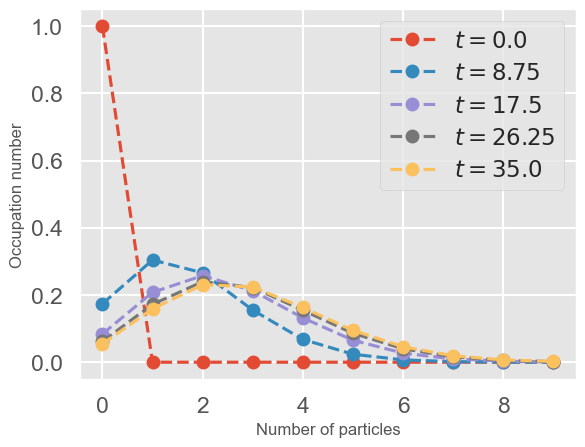

In [ ]:
# Master Equations
def J(x, mu, nu):
    """
    Time derivative of the occupation numbers.

        * x is the state distribution (array like)
        * t is time (scalar) - removed since unused
        * mu is the birth rate
        * nu is the particle death rate
    """
    
    dx = 0*x
    for n in range(len(x)):
        if n==0: #for first state
            dx[0] = - mu*x[0] + nu*x[1]
        elif n==len(x)-1: #for last state
            dx[n] = -(nu*n)*x[n] + mu*x[n-1]
        else: #all other states
            dx[n] = -(mu+nu*n)*x[n] + nu*(n+1)*x[n+1] + mu*x[n-1]

    return dx

# Time of observations
t_length = 35
t_steps = 5
t_vec = np.linspace(0, t_length, t_steps)

# Initial conditions
nb_of_states = 10
x_0 = np.zeros(nb_of_states)
x_0[0] = 1

# Parameters
mu = 0.3
nu = 0.1

# Integration
G = lambda x, t: J(x, mu, nu)
x_path = odeint(G, x_0, t_vec)

# Plot
for t in range(t_steps):
    plt.plot(range(nb_of_states),x_path[t], marker="o", ls='--', label=fr"$t = {t_vec[t]}$")
plt.legend()
plt.ylabel('Occupation number')
plt.xlabel('Number of particles')
plt.show()